## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [15]:
# import lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# Download
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: /Users/baojianing/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [17]:
import os
os.listdir(path)

['amz_uk_price_prediction_dataset.csv']

In [18]:
raw_data = pd.read_csv(path + '/amz_uk_price_prediction_dataset.csv')
df = raw_data.copy()
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


In [19]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [20]:
crosstab_c_best = pd.crosstab(df['category'], df['isBestSeller'])
crosstab_c_best.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [21]:
crosstab_c_best_copy = crosstab_c_best.copy()
crosstab_c_best_copy

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [22]:
crosstab_c_best['pct'] = crosstab_c_best[True] / (crosstab_c_best[True]+crosstab_c_best[False])

crosstab_c_best.sort_values("pct", ascending= False).head(10)

isBestSeller,False,True,pct
category,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339
"Billiard, Snooker & Pool",241,8,0.032129
Pet Supplies,9152,285,0.030200
Home Brewing & Wine Making,239,7,0.028455
Wind Instruments,243,7,0.028000


-Q: Are there categories where being a best-seller is more prevalent? 

-A: Yes, Grocery, Smart Home Security & Lighting, and Health & Personal Care are the top 3 categories which tend to be BestSellers. 

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.

In [23]:
from scipy.stats import chi2_contingency

In [24]:
_, chi2_pvalue, _, _ = chi2_contingency(crosstab_c_best_copy)
float(chi2_pvalue)

0.0

--- Answer:

--- The P value here is much less than 0.05, which indicates a dependance between categories and best seller. 

- Compute Cramér's V to understand the strength of association between best-seller status and category.

In [25]:
from scipy.stats.contingency import association

In [26]:
association(crosstab_c_best_copy, method='cramer')

0.1222829439760564

---There is week association（0.1 -0.2） between best-seller status and category.



3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

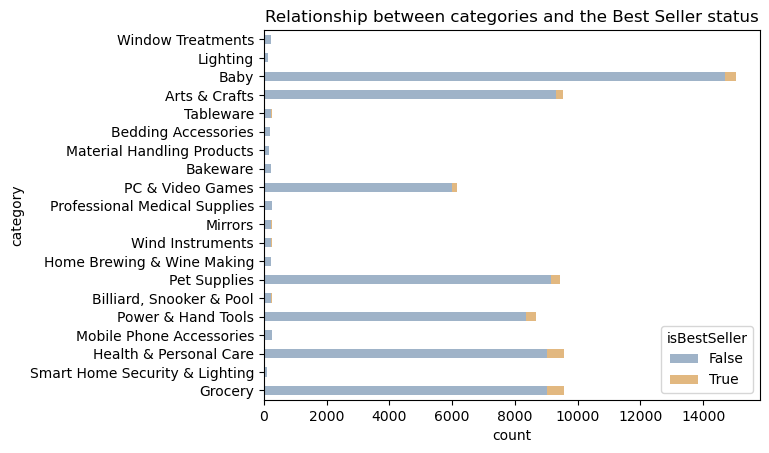

In [64]:
forbar = crosstab_c_best.sort_values('pct', ascending= False).head(20)   # choose 20
forbar.drop(columns='pct').plot(kind= 'barh', stacked=True, color =['#9FB3C8', '#E2B880'])  # pct not in diagram
plt.title('Relationship between categories and the Best Seller status')
plt.ylabel('category')
plt.xlabel('count')
plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*


In [28]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [ ]:
#find the outlier
oprice_q1 = df['price'].quantile(0.25)
oprice_q3 = df['price'].quantile(0.75)
iqr_price = oprice_q3-oprice_q1
lw_bd = oprice_q1 - 1.5* iqr_price
hi_bd = oprice_q3 + 1.5*iqr_price
df_noout = df[(df['price']>=lw_bd) & (df['price']<=hi_bd)]  #remove outliers
df_noout.sample()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2142583,2484990,B0CBNFJRJT,Scorpion on Dome Silver coloured Cufflinks per...,0.0,0,9.99,False,0,Handmade Jewellery



1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.


In [30]:
forbar # the top20 categories from last step

isBestSeller,False,True,pct
category,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339
"Billiard, Snooker & Pool",241,8,0.032129
Pet Supplies,9152,285,0.030200
Home Brewing & Wine Making,239,7,0.028455
Wind Instruments,243,7,0.028000


/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_6129/1770496532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = top20, y = 'category', x='price', order=forbar.index, palette= "crest" ) # this direction better to see


Text(0.5, 1.0, 'Price distribution')

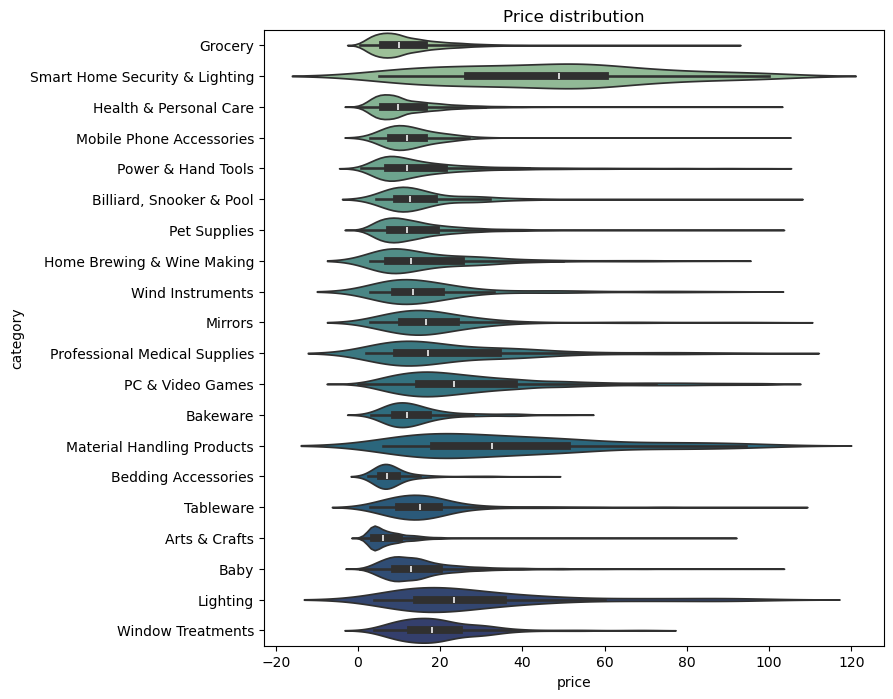

In [31]:
#choose head 20
plt.figure(figsize= (8, 8))
top20= df_noout[df_noout['category'].isin(forbar.index)]
sns.violinplot(data = top20, y = 'category', x='price', order=forbar.index, palette= "crest" ) # this direction better to see

plt.title('Price distribution')

In [32]:
#- Which product category tends to have the highest median price? Don't filter here by top categories.

df_median = df_noout.groupby('category')['price'].median().sort_values(ascending= False)
df_median


category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

---- Desktop PCs tends to have the highest median price.


2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.


In [33]:
# 10 product categories
top10_counts = df_noout['category'].value_counts().head(10).reset_index()
top10_counts


,category,count
0,Sports & Outdoors,694092
1,Beauty,19233
2,Bath & Body,19050
3,Manicure & Pedicure Products,18904
4,"Handmade Clothing, Shoes & Accessories",18811
5,Make-up,18718
6,Skin Care,18686
7,Hair Care,18625
8,Birthday Gifts,18398
9,Handmade Gifts,17948


/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_6129/2615662774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= top10_ave.values, y= top10_ave.index, palette= 'crest')


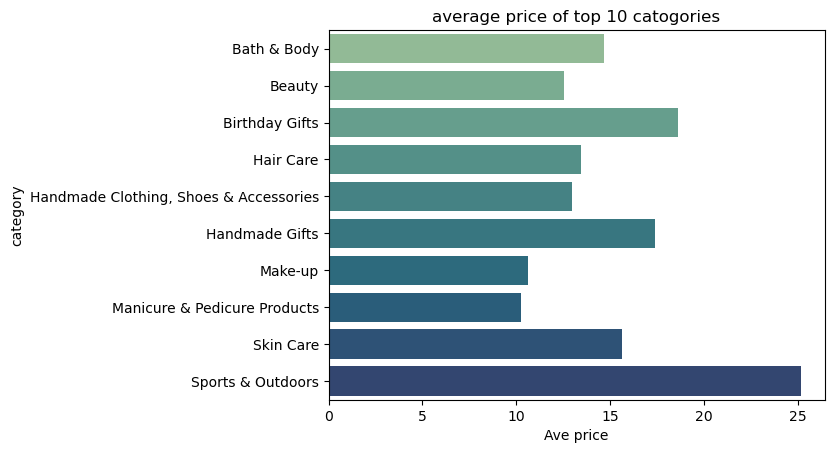

In [65]:
#cal ave
top10 = df_noout[df_noout['category'].isin(top10_counts['category'])]

top10_ave = top10.groupby('category')['price'].mean()
# bar chart
plt.Figure(figsize= (2,1))
sns.barplot(x= top10_ave.values, y= top10_ave.index, palette= 'crest')
plt.title('average price of top 10 catogories')
plt.xlabel('Ave price')
plt.tight_layout
plt.show()


In [35]:
#- Which product category commands the highest average price? Don't filter here by top categories.
price_ave = df_noout.groupby('category')['price'].mean().sort_values(ascending=False)
price_ave

# We can see here Motherboards has the highest average price among all of the categories.

category
Motherboards             68.772432
Boxing Shoes             67.417803
Desktop PCs              66.915562
Tablets                  66.552971
Graphics Cards           65.103509
                           ...    
Bedding Accessories       8.835220
Adapters                  8.750197
Signs & Plaques           8.210513
Arts & Crafts             8.006540
Office Paper Products     6.876369
Name: price, Length: 296, dtype: float64


3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_6129/1981779655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= top10_rating, y= 'category', x='stars', palette= 'crest')


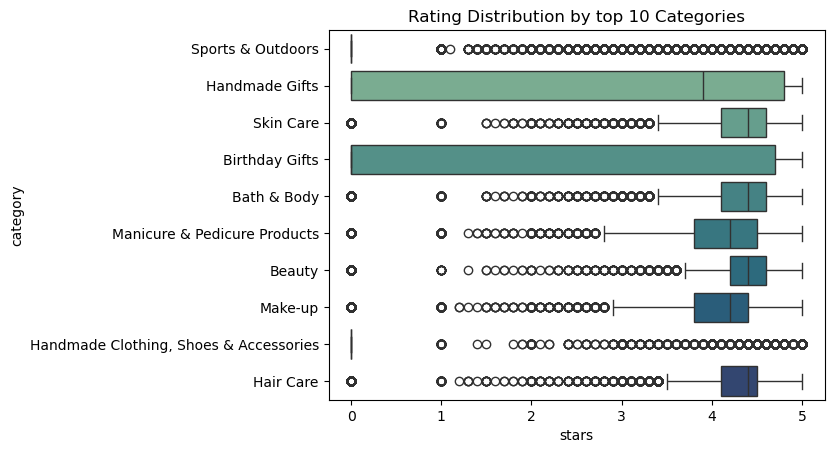

In [36]:

top10_rating = df_noout[df_noout['category'].isin(top10_counts['category'])]

sns.boxplot(data= top10_rating, y= 'category', x='stars', palette= 'crest')
plt.xlabel('stars')
plt.title('Rating Distribution by top 10 Categories')
plt.show()


In [37]:
# - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.
rating_median = df_noout.groupby('category')['stars'].median().sort_values(ascending= False)
rating_median

# Computer Memory tends to receive the highest median rating from customers.

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
                               ... 
Hockey Shoes                    0.0
Hi-Fi Receivers & Separates     0.0
Handmade Kitchen & Dining       0.0
Handmade Jewellery              0.0
eBook Readers & Accessories     0.0
Name: stars, Length: 296, dtype: float64

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?


In [38]:
# Spearman
round(float(df_noout["price"].corr(df_noout["stars"], method="pearson")), 3)

-0.078

In [39]:
# Spearman
round(float(df_noout["price"].corr(df_noout["stars"], method="spearman")), 3)

-0.067

- Is there a significant correlation between product price and its rating?

- NO. almost zero.

	
2. **Visualizations**:
- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?


/var/folders/63/dzhzcn696dbdv60g_f7p4wb80000gn/T/ipykernel_6129/1761787072.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_noout, x= 'stars', y = 'price', palette='crest')


<Axes: xlabel='stars', ylabel='price'>

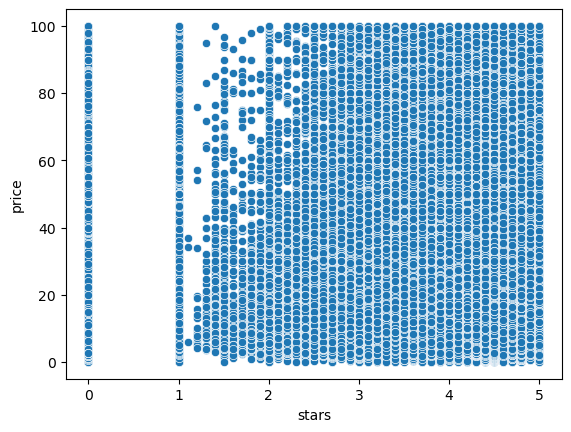

In [40]:
sns.scatterplot(data=df_noout, x= 'stars', y = 'price', palette='crest')

--It will be hardly to observe.

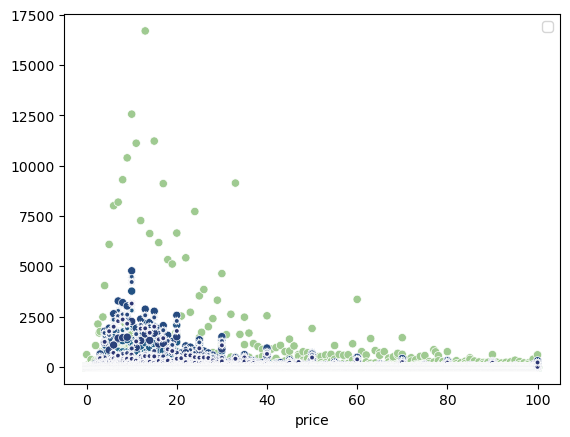

In [47]:
rel_p_stars= pd.crosstab(df_noout['price'], df_noout['stars'])
sns.scatterplot(data=rel_p_stars, palette='crest')
plt.legend('')
plt.show()

    - Use a correlation heatmap to visualize correlations between all numerical variables.


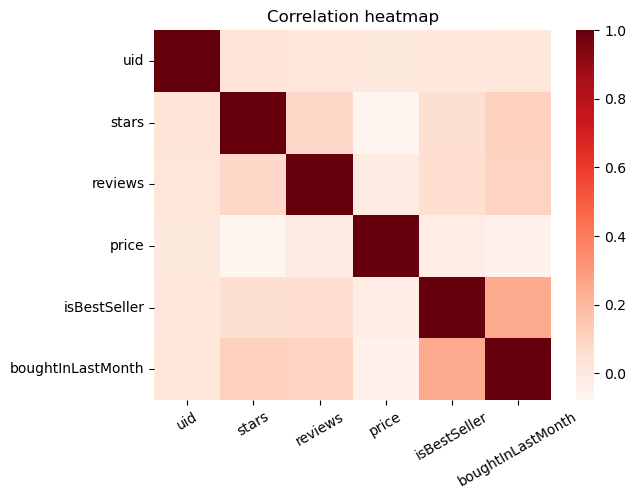

In [58]:
rel_all= df_noout.corr(numeric_only=True)

sns.heatmap(
    rel_all,
    annot=False,
    cmap='Reds',
    fmt='.2f'
)
plt.title('Correlation heatmap')
plt.xticks(rotation= 30)
plt.show()


    - Examine if product prices typically follow a normal distribution using a QQ plot. 


In [59]:
!pip install statsmodels

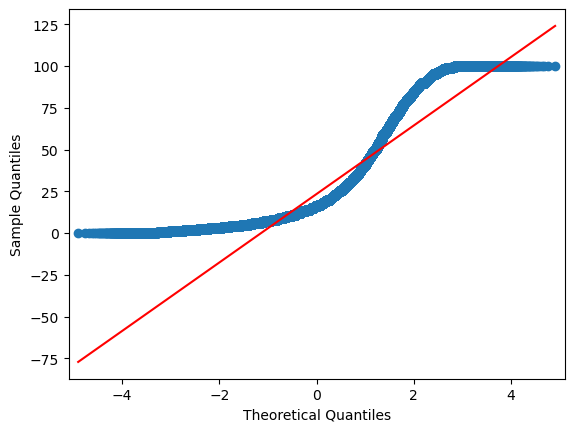

In [60]:
import statsmodels.api as sm
sm.qqplot(df_noout['price'], line='s');
plt.show()

---No, is not a normal distribution.

The QQ plot shows a S-shaped pattern, is not normally distributed.
